1. Loading VAE to encode...
원본 잠재 벡터(latents) 범위: 최소 -38.75 ~ 최대 31.49
원본 잠재 벡터의 표준편차: 4.52
   - VAE Model Size: 319.11 MB
   - Latent Data Size: 64.00 KB
--------------------------------------------------
2. Deleting VAE model and clearing memory...
3. Re-initializing VAE model from scratch...


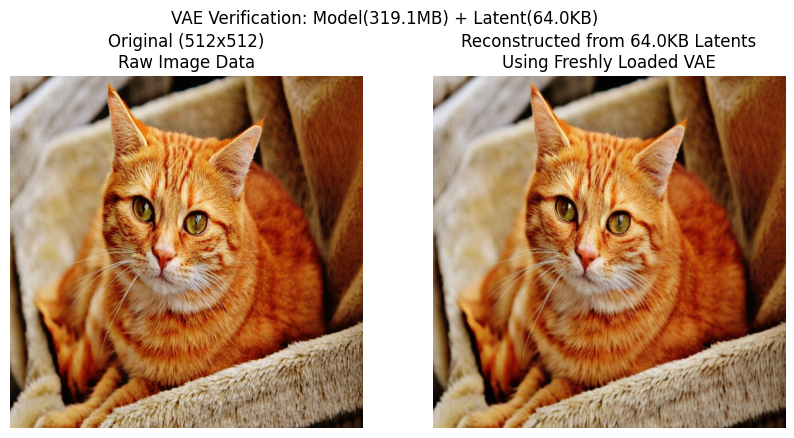

Success: The image was perfectly restored using only the saved latents and a re-initialized model!


In [ ]:
import torch
import os
import gc
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import AutoencoderKL
from torchvision import transforms

# 1. 모델 크기 계산 함수
def get_model_size_mb(model):
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    return param_size / (1024 * 1024)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "stabilityai/sd-vae-ft-mse" # https://laion.ai/blog/laion-aesthetics/

# [Phase 1: 인코딩 및 Latent 추출]
print(f"1. Loading VAE to encode...")
vae = AutoencoderKL.from_pretrained(model_id).to(device)
vae_size = get_model_size_mb(vae)

# 이미지 로드 (cat3.jpg)
img = Image.open("cat3.jpg").convert("RGB").resize((512, 512))
preprocess = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    # 이미지를 64x64x4의 Latent로 압축
    latent_space = vae.encode(input_tensor)
    latents = latent_space.latent_dist.mode()

    print(f"원본 잠재 벡터(latents) 범위: 최소 {latents.min().item():.2f} ~ 최대 {latents.max().item():.2f}")
    print(f"원본 잠재 벡터의 표준편차: {latents.std().item():.2f}")

# Latent 데이터 용량 계산 (float32 기준)
latent_size_kb = (latents.nelement() * latents.element_size()) / 1024

print(f"   - VAE Model Size: {vae_size:.2f} MB")
print(f"   - Latent Data Size: {latent_size_kb:.2f} KB")
print("-" * 50)

# [Phase 2: 모델 파괴 및 메모리 정리]
print("2. Deleting VAE model and clearing memory...")
del vae
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# [Phase 3: 모델 재초기화 및 복원]
print("3. Re-initializing VAE model from scratch...")
vae_new = AutoencoderKL.from_pretrained(model_id).to(device)

with torch.no_grad():
    # 새로 띄운 모델에 기존에 뽑아둔 latents만 입력해서 복원
    reconstructed = vae_new.decode(latents).sample

# 결과 이미지 처리
recon_img = (reconstructed / 2 + 0.5).clamp(0, 1)
recon_img = recon_img[0].cpu().permute(1, 2, 0).numpy()

# [Phase 4: 시각화 및 증명]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img)
axes[0].set_title(f"Original (512x512)\nRaw Image Data")
axes[0].axis("off")

axes[1].imshow(recon_img)
axes[1].set_title(f"Reconstructed from {latent_size_kb:.1f}KB Latents\nUsing Freshly Loaded VAE")
axes[1].axis("off")

plt.suptitle(f"VAE Verification: Model({vae_size:.1f}MB) + Latent({latent_size_kb:.1f}KB)")
plt.show()

print("Success: The image was perfectly restored using only the saved latents and a re-initialized model!")

Using device: cuda
Generating 8x8 Latent Space Manifold. Please wait...


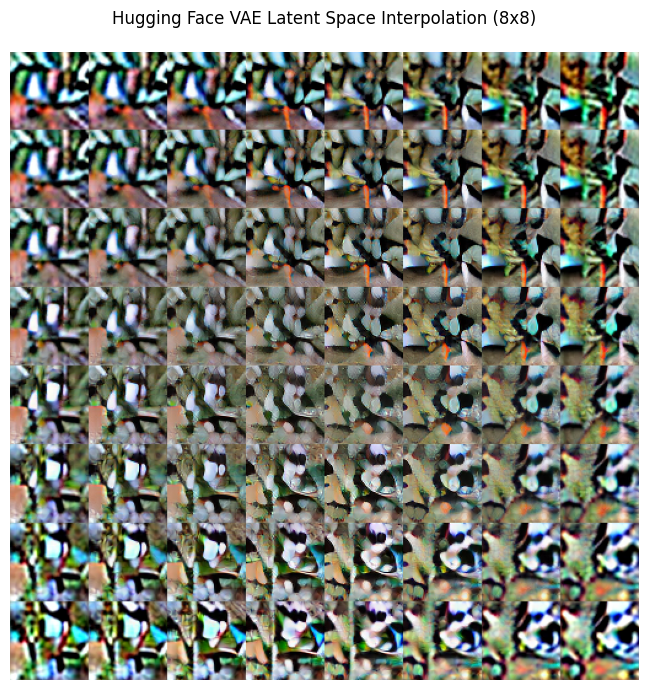

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffusers import AutoencoderKL

# 1. 디바이스 설정 및 VAE 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Downloading VAE model from Hugging Face...")

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)

# 2. 잠재 공간(Latent Space)의 4개 꼭짓점 생성 (4x8x8 차원)
shape = (1, 4, 8, 8)
torch.manual_seed(42) # 동일한 결과를 위해 시드 고정
z_top_left = torch.randn(shape, device=device)
z_top_right = torch.randn(shape, device=device)
z_bottom_left = torch.randn(shape, device=device)
z_bottom_right = torch.randn(shape, device=device)

# 3. 8x8 그리드 이미지 캔버스 준비 (64 * 8 = 512 픽셀)
n = 8  # <16에서 8로 수정된 부분입니다.
grid_size = 64
figure = np.zeros((grid_size * n, grid_size * n, 3))

print("Generating 8x8 Latent Space Manifold. Please wait...")

# 4. 보간(Interpolation) 및 디코딩
with torch.no_grad():
    for i in range(n):
        for j in range(n):
            # 가로(u)와 세로(v)의 보간 비율 계산 (0.0 ~ 1.0)
            u = j / (n - 1)
            v = i / (n - 1)
            
            # 잠재 벡터 섞기 (Bilinear Interpolation)
            z_top = (1 - u) * z_top_left + u * z_top_right
            z_bottom = (1 - u) * z_bottom_left + u * z_bottom_right
            z_current = (1 - v) * z_top + v * z_bottom
            
            # VAE 표준 스케일링 적용 후 디코딩
            z_scaled = z_current / vae.config.scaling_factor
            decoded = vae.decode(z_scaled).sample
            
            # 이미지를 0~1 사이로 정규화
            decoded = (decoded / 2 + 0.5).clamp(0, 1)
            img = decoded[0].cpu().permute(1, 2, 0).numpy()
            
            # 8x8 캔버스에 생성된 이미지 채워넣기
            figure[i * grid_size : (i + 1) * grid_size,
                   j * grid_size : (j + 1) * grid_size, :] = img

# 5. 결과 시각화
plt.figure(figsize=(7, 7))
plt.imshow(figure)
plt.title("Hugging Face VAE Latent Space Interpolation (8x8)", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()